<a href="https://colab.research.google.com/github/nika19du/LangGraph-Agent-Workflows/blob/master/Multi_Agent_AI_Developer_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langgraph langchain langchain-openai langchain-anthropic

In [2]:
import os
import subprocess

from IPython.display import Image
from google.colab import userdata
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from typing import Annotated, List, TypedDict, Literal
from langchain_core.runnables import Runnable

from langchain_core.messages import HumanMessage, SystemMessage,BaseMessage
from langchain_core.tools import tool

from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.types import interrupt, Command
from langgraph.prebuilt import ToolNode

openai_api_key = SecretStr(userdata.get('OPENAI_API_KEY'))

anthropic_api_key = userdata.get("ANTHROPIC_API_KEY")

print("Loaded:", anthropic_api_key is not None)
print("Length:", len(anthropic_api_key) if anthropic_api_key else 0)
print("Prefix:", anthropic_api_key[:10] if anthropic_api_key else None)

def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph().draw_mermaid_png())

    display(Image(output_png, format="png"))


Loaded: True
Length: 108
Prefix: sk-ant-api


In [3]:
coding_model = ChatOpenAI(
    model = "gpt-5.6-luna",
    api_key=openai_api_key,
    reasoning_effort="none"
)

review_model=ChatAnthropic(
    model="claude-sonnet-4-6",
    api_key= anthropic_api_key
)

## Coding Sub-graph

In [4]:
class ReviewResult(BaseModel):
    status: Literal["approved","changes_required"] = Field(description="Whether the proposed solution is approved or needs revision.")
    score: int = Field(ge=1, le= 10, description="Overall code quality score from 1 to 10.")
    issues: list[str] = Field(default="", description="Problems found in the proposed implementation.")
    feedback: str = Field(default="", description = "Specific instructions for the coding agent if revision is needed.")


class CodingState(TypedDict):
    user_request: str
    task_type: Literal['create', 'modify']

    file_path:str
    original_content: str
    proposed_content: str

    review: ReviewResult | None

    human_feedback: str
    revision_count: int
    final_answer: str

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
structured_review_model = review_model.with_structured_output(ReviewResult)

structured_review_model = review_model.with_structured_output(ReviewResult)

In [6]:
@tool
def read_file(file_path: str) -> str:
    """
    Read a text-based file from the Google Colab enviornment.

    Args:
        file_path: Absolute or relative path to the file.

    Returns:
        The file content as a string.
    """

    path = Path(file_path)

    if not path.exists():
        return f"Error: File '{file_path}' not found."

    if not path.is_file():
        return f"Error: '{file_path}' is not a file."

    try:
      with path.open(mode="r") as file:
          return file.read()
    except Exception as e:
        return f"Error: Could not read file: {e}"


@tool
def write_file(file_path: str, content: str) -> str:
    """
    Write approved text content to a file in the Google Colab environment.

    This tool should only be used after human approval.

    Args:
      file_path: Path to the target file.
      content: Full content that should be written.

    Returns:
      A status message.
    """

    path = Path(file_path)

    try:
        path.parent.mkdir(
            parents = True,
            exist_ok = True
        )

        path.write_text(
            content,
            encoding="utf-8"
        )

        return f"Success: File '{file_path}' was updated."

    except Exception as e:
          return f"Error: Could not write file: {e}"

@tool
def run_python_file(file_path: str) -> str:
    """
    Execute a Python file and return stdout, stderr and exit code.

    Args:
        file_path: Path to a Python file.

    Returns:
        Execution result.
    """

    path = Path(file_path)

    if not path.exists():
        return f"ERROR: File '{file_path}' does not exist."

    if path.suffix != ".py":
        return "ERROR: Only Python files can be executed."

    try:
        result = subprocess.run(
            ["python", str(path)],
            capture_output=True,
            text=True,
            timeout=10
        )

        return (
            f"Exit code: {result.returncode}\n\n"
            f"STDOUT:\n{result.stdout}\n"
            f"STDERR:\n{result.stderr}"
        )

    except subprocess.TimeoutExpired:
        return "ERROR: Execution exceeded the 10 second timeout."

    except Exception as e:
        return f"ERROR: Could not execute file: {e}"

In [7]:
coding_tools = [
    read_file,
    run_python_file
]

coding_model_with_tools = coding_model.bind_tools(coding_tools)

tool_node = ToolNode(coding_tools)

In [8]:
CODING_SYSTEM_PROMPT = """
You are a senior Python software engineer.

Your task is to create or modify code based on the user's request.

If the task is to modify an existing file:
- use the read_file tool to inspect the current file content;
- do not write directly to the file;
- return the full proposed updated content.

If the task is to create new code:
- generate the complete implementation.

If reviewer or human feedback is available, revise the previous proposal accordingly.
"""

REVIEWER_SYSTEM_PROMPT = """
You are a strict senior software engineer performing a code review.

Review the proposed implementation against the original user request.

Evaluate:
- correctness
- edge cases
- readability
- maintainability
- potential bugs
- whether the implementation fully satisfies the request

Give a score from 1 to 10.

Use status "approved" only if the implementation is correct and does not
require meaningful changes.

Use status "changes_required" if changes are necessary.

When changes are required:
- list the identified issues;
- provide specific and actionable feedback for the coding agent.
"""

In [9]:
def strip_code_fences(content: str) -> str:
    content = content.strip()

    if content.startswith("```"):
        lines = content.splitlines()

        if lines[0].startswith("```"):
            lines = lines[1:]

        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]

        return "\n".join(lines)

    return content

In [10]:
def coding_agent(state: CodingState):
    context_message = HumanMessage(
        content=f"""
                User request:
                {state["user_request"]}

                Task type:
                {state["task_type"]}

                File path:
                {state.get("file_path", "")}

                Reviewer feedback:
                {state.get("review").feedback if state.get("review") else ""}

                Human feedback:
                {state.get("human_feedback", "")}
                """
    )


    messages = [
        SystemMessage(content=CODING_SYSTEM_PROMPT),
        context_message,
        *state.get("messages", [])
    ]

    response = coding_model_with_tools.invoke(messages)


    result = {
        "messages": [response]
    }

    if not response.tool_calls and response.content:
        result['proposed_content'] = strip_code_fences(response.content)

    return result

def route_after_coding(state: CodingState):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "end"


def code_reviewer(state: CodingState):
    messages= [
        SystemMessage(content = REVIEWER_SYSTEM_PROMPT),
        HumanMessage(
            content=f"""
                Original user request:
                {state["user_request"]}

                Proposed implementation:
                {state["proposed_content"]}
            """
        )
    ]

    review = structured_review_model.invoke(messages)

    return {
        "review": review
    }

In [11]:
test_state = {
    "user_request": "Create a Python function that returns the maximum number from a list.",
    "task_type": "create",
    "file_path": "",
    "original_content": "",
    "proposed_content": "",
    "review": None,
    "human_feedback": "",
    "revision_count": 0,
    "final_answer": "",
    "messages": []
}

In [12]:
result = coding_agent(test_state)

In [13]:
result["messages"][-1].content

'```python\ndef maximum_number(numbers: list[float | int]) -> float | int:\n    """Return the largest number in a non-empty list.\n\n    Raises:\n        ValueError: If the list is empty.\n        TypeError: If an item is not an int or float.\n    """\n    if not numbers:\n        raise ValueError("numbers must not be empty")\n\n    if not all(isinstance(number, (int, float)) for number in numbers):\n        raise TypeError("all items must be numbers")\n\n    return max(numbers)\n```'

In [14]:
result["messages"][-1].tool_calls

[]

In [15]:
result

{'messages': [AIMessage(content='```python\ndef maximum_number(numbers: list[float | int]) -> float | int:\n    """Return the largest number in a non-empty list.\n\n    Raises:\n        ValueError: If the list is empty.\n        TypeError: If an item is not an int or float.\n    """\n    if not numbers:\n        raise ValueError("numbers must not be empty")\n\n    if not all(isinstance(number, (int, float)) for number in numbers):\n        raise TypeError("all items must be numbers")\n\n    return max(numbers)\n```', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 336, 'total_tokens': 450, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-EM9

In [16]:
Path("/content/example.py").write_text(
    """
def divide(a, b):
    return a / b
""".strip(),
    encoding="utf-8"
)

34

In [17]:
modify_state = {
    "user_request": "Modify the file to handle division by zero.",
    "task_type": "modify",
    "file_path": "/content/example.py",
    "original_content": "",
    "proposed_content": "",
    "review": None,
    "human_feedback": "",
    "revision_count": 0,
    "final_answer": "",
    "messages": []
}

result = coding_agent(modify_state)

In [18]:
result["messages"][-1].tool_calls

[{'name': 'read_file',
  'args': {'file_path': '/content/example.py'},
  'id': 'call_M69XKk9UMnhlJrrO3LC5TfET',
  'type': 'tool_call'}]

In [19]:
test_builder = StateGraph(CodingState)

test_builder.add_node('coding_agent', coding_agent)
test_builder.add_node('tools', tool_node)

test_builder.add_edge(START, "coding_agent")

test_builder.add_conditional_edges(
    "coding_agent",
    route_after_coding,
    {
        "tools": "tools",
        "end": END
    }
)

test_builder.add_edge("tools", "coding_agent")

test_graph= test_builder.compile()

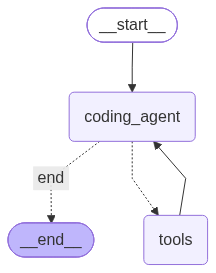

In [20]:
display_graph(test_graph, Path("test_graph.png"))

In [21]:
Path("/content/example.py").write_text(
    """def divide(a, b):
    return a / b
""",
    encoding="utf-8"
)

35

In [22]:
modify_state = {
    "user_request": "Modify the file to handle division by zero.",
    "task_type": "modify",
    "file_path": "/content/example.py",
    "original_content": "",
    "proposed_content": "",
    "review": None,
    "human_feedback": "",
    "revision_count": 0,
    "final_answer": "",
    "messages": []
}

In [23]:
result = test_graph.invoke(modify_state)

In [24]:
print(result["proposed_content"])

def divide(a, b):
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b


In [25]:
for message in result["messages"]:
    print("=" * 50)
    print(type(message).__name__)
    print("CONTENT:")
    print(message.content)

    if hasattr(message, "tool_calls"):
        print("TOOL CALLS:")
        print(message.tool_calls)

AIMessage
CONTENT:

TOOL CALLS:
[{'name': 'read_file', 'args': {'file_path': '/content/example.py'}, 'id': 'call_Bn2uknya4io0ZLypF0piNBHH', 'type': 'tool_call'}]
ToolMessage
CONTENT:
def divide(a, b):
    return a / b

AIMessage
CONTENT:
```python
def divide(a, b):
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b
```
TOOL CALLS:
[]


In [26]:
review_test_state = {
    "user_request": "Modify the function to handle division by zero.",
    "task_type": "modify",
    "file_path": "/content/example.py",
    "original_content": "def divide(a, b):\n    return a / b",
    "proposed_content": """
def divide(a, b):
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b
""",
    "review": None,
    "human_feedback": "",
    "revision_count": 0,
    "final_answer": "",
    "messages": []
}

review_result = code_reviewer(review_test_state)

print(review_result)

{'review': ReviewResult(status='approved', score=9, issues='', feedback='The implementation is clean, correct, and satisfies the request. One minor consideration: depending on the use case, raising a `ZeroDivisionError` instead of `ValueError` might be more semantically appropriate, as it is the standard Python exception for this scenario. However, `ValueError` is still a valid and acceptable choice.')}
